In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import FunctionTransformer

In [3]:
df = pd.read_csv(r"C:\Users\Prakash\Downloads\drug_regulatory_classification_dataset.csv")        #loading dataset
df.head()                                                                                         #first five rows


,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Manufacturing_Region,Requires_Cold_Storage,OTC_Flag,High_Risk_Substance,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate,Target_Regulatory_Class
0,250,364.22,246.49,159132.53,3,4.26,2.52,0.74,57.93,42.07,...,South,No,No,No,64.46,41.88,41.15,6.56,0.47,Non-Regulated Drug
1,500,112.86,73.22,260595.45,2,8.12,1.80,0.48,48.00,52.00,...,East,Yes,Yes,No,93.37,10.30,50.05,4.01,0.44,Non-Regulated Drug
2,200,197.24,100.72,106818.45,3,1.58,1.47,0.93,54.48,45.52,...,North,Yes,Yes,No,64.53,34.21,46.42,5.95,0.16,Non-Regulated Drug
3,500,373.55,264.76,231304.59,4,1.72,1.61,0.54,47.20,52.80,...,North,No,Yes,No,95.21,71.04,49.52,9.65,0.76,Non-Regulated Drug
4,500,353.87,277.29,319403.02,2,9.64,0.45,0.50,86.96,13.04,...,North,No,Yes,No,98.05,70.28,44.90,1.79,0.36,Non-Regulated Drug


In [4]:
df.shape

(60000, 30)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Dosage_mg                         60000 non-null  int64  
 1   Price_Per_Unit                    60000 non-null  float64
 2   Production_Cost                   60000 non-null  float64
 3   Marketing_Spend                   60000 non-null  float64
 4   Clinical_Trial_Phase              60000 non-null  int64  
 5   Side_Effect_Severity_Score        60000 non-null  float64
 6   Abuse_Potential_Score             60000 non-null  float64
 7   Prescription_Rate                 60000 non-null  float64
 8   Hospital_Distribution_Percentage  60000 non-null  float64
 9   Pharmacy_Distribution_Percentage  60000 non-null  float64
 10  Annual_Sales_Volume               60000 non-null  float64
 11  Regulatory_Risk_Score             60000 non-null  float64
 12  Appr

In [7]:
df.describe()                                   # generate descriptive statistics 

,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Patent_Duration_Years,R&D_Investment_Million,Competitor_Count,Recall_History_Count,Adverse_Event_Reports,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate
count,60000.000000,60000.000000,60000.000000,6.000000e+04,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,292.434167,253.312360,151.954054,2.669683e+05,2.502750,5.498936,2.847217,0.526119,47.411735,52.588265,...,9.986983,100.536433,11.968967,0.499533,4.996517,59.793295,39.993931,29.900791,5.476783,0.525048
std,214.975937,142.948109,92.028388,1.831812e+05,1.118055,2.604378,1.592573,0.245659,24.529169,24.529169,...,5.459745,57.332576,7.223363,0.708925,2.236252,23.046536,23.107853,17.313127,2.597910,0.244788
min,50.000000,5.020000,2.070000,1.000535e+04,1.000000,1.000000,0.010000,0.100000,5.000000,10.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,20.000000,0.000000,0.010000,1.000000,0.100000
25%,100.000000,129.790000,75.087500,1.335899e+05,2.000000,3.230000,1.610000,0.310000,26.150000,31.480000,...,5.000000,51.070000,6.000000,0.000000,3.000000,39.740000,19.900000,14.860000,3.230000,0.310000
50%,250.000000,252.870000,146.395000,2.583855e+05,3.000000,5.500000,2.630000,0.530000,47.450000,52.550000,...,10.000000,100.750000,12.000000,0.000000,5.000000,59.740000,39.990000,29.990000,5.470000,0.530000
75%,500.000000,377.572500,218.752500,3.819740e+05,4.000000,7.750000,3.880000,0.740000,68.520000,73.850000,...,15.000000,150.170000,18.000000,1.000000,6.000000,79.680000,59.950000,44.800000,7.720000,0.740000
max,650.000000,499.960000,398.290000,1.999699e+06,4.000000,10.000000,9.350000,0.950000,90.000000,95.000000,...,19.000000,200.000000,24.000000,6.000000,16.000000,100.000000,80.000000,60.000000,10.000000,0.950000


In [8]:
df.describe(include='object')          # generate descriptive statistics              

,Drug_Form,Therapeutic_Class,Manufacturing_Region,Requires_Cold_Storage,OTC_Flag,High_Risk_Substance,Target_Regulatory_Class
count,60000,60000,60000,60000,60000,60000,57000
unique,4,5,4,2,2,2,2
top,Syrup,Analgesic,South,Yes,Yes,No,Non-Regulated Drug
freq,15181,12085,15158,30003,30038,57612,42130


In [9]:
df.isnull().sum()         #check missing values

Dosage_mg                              0
Price_Per_Unit                         0
Production_Cost                        0
Marketing_Spend                        0
Clinical_Trial_Phase                   0
Side_Effect_Severity_Score             0
Abuse_Potential_Score                  0
Prescription_Rate                      0
Hospital_Distribution_Percentage       0
Pharmacy_Distribution_Percentage       0
Annual_Sales_Volume                    0
Regulatory_Risk_Score                  0
Approval_Time_Months                   0
Patent_Duration_Years                  0
R&D_Investment_Million                 0
Competitor_Count                       0
Recall_History_Count                   0
Adverse_Event_Reports                  0
Drug_Form                              0
Therapeutic_Class                      0
Manufacturing_Region                   0
Requires_Cold_Storage                  0
OTC_Flag                               0
High_Risk_Substance                    0
Insurance_Covera

In [10]:
#handling missing values

# Before
print("Before:", df.shape)  # (60000, 30)

# Drop missing target rows
df.dropna(subset=['Target_Regulatory_Class'], inplace=True)

# After
print("After:", df.shape)   # (57000, 30)
print("Missing labels left:", df['Target_Regulatory_Class'].isnull().sum())  # 0

Before: (60000, 30)
After: (57000, 30)
Missing labels left: 0


In [11]:
cat_cols = ['Drug_Form', 'Therapeutic_Class', 'Manufacturing_Region',
            'Requires_Cold_Storage', 'OTC_Flag', 'High_Risk_Substance']

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Drug_Form:
Drug_Form
Syrup        14437
Capsule      14249
Tablet       14219
Injection    14095
Name: count, dtype: int64

Therapeutic_Class:
Therapeutic_Class
Analgesic         11505
Antidepressant    11451
Antibiotic        11376
Antiviral         11343
Cardiovascular    11325
Name: count, dtype: int64

Manufacturing_Region:
Manufacturing_Region
South    14401
East     14328
North    14141
West     14130
Name: count, dtype: int64

Requires_Cold_Storage:
Requires_Cold_Storage
Yes    28507
No     28493
Name: count, dtype: int64

OTC_Flag:
OTC_Flag
Yes    28530
No     28470
Name: count, dtype: int64

High_Risk_Substance:
High_Risk_Substance
No     54733
Yes     2267
Name: count, dtype: int64


Target_Regulatory_Class
Non-Regulated Drug    42130
Regulated Drug        14870
Name: count, dtype: int64
Target_Regulatory_Class
Non-Regulated Drug    73.912281
Regulated Drug        26.087719
Name: proportion, dtype: float64


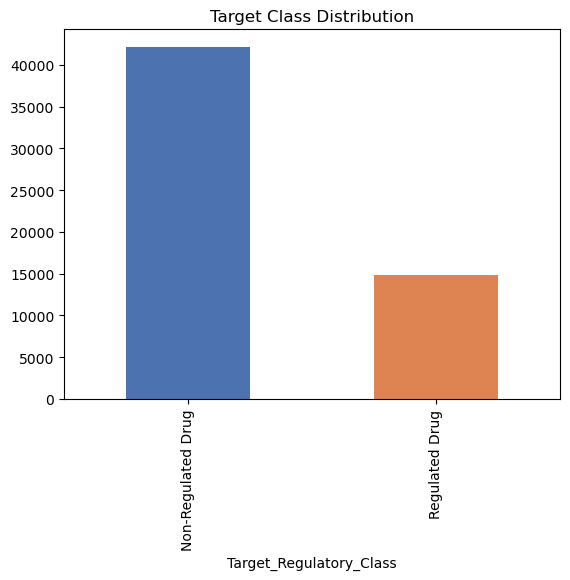

In [12]:
import matplotlib.pyplot as plt

# Count each class
print(df['Target_Regulatory_Class'].value_counts())
print(df['Target_Regulatory_Class'].value_counts(normalize=True) * 100)  # percentages

# Visualize
df['Target_Regulatory_Class'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452'])
plt.title('Target Class Distribution')
plt.show()

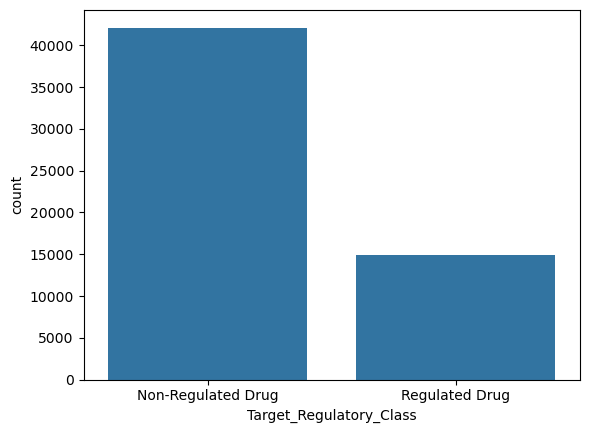

In [13]:
df['Target_Regulatory_Class'].value_counts()
sns.countplot(x='Target_Regulatory_Class', data=df)
plt.show()


array([[<Axes: title={'center': 'Dosage_mg'}>,
        <Axes: title={'center': 'Price_Per_Unit'}>,
        <Axes: title={'center': 'Production_Cost'}>,
        <Axes: title={'center': 'Marketing_Spend'}>,
        <Axes: title={'center': 'Clinical_Trial_Phase'}>],
       [<Axes: title={'center': 'Side_Effect_Severity_Score'}>,
        <Axes: title={'center': 'Abuse_Potential_Score'}>,
        <Axes: title={'center': 'Prescription_Rate'}>,
        <Axes: title={'center': 'Hospital_Distribution_Percentage'}>,
        <Axes: title={'center': 'Pharmacy_Distribution_Percentage'}>],
       [<Axes: title={'center': 'Annual_Sales_Volume'}>,
        <Axes: title={'center': 'Regulatory_Risk_Score'}>,
        <Axes: title={'center': 'Approval_Time_Months'}>,
        <Axes: title={'center': 'Patent_Duration_Years'}>,
        <Axes: title={'center': 'R&D_Investment_Million'}>],
       [<Axes: title={'center': 'Competitor_Count'}>,
        <Axes: title={'center': 'Recall_History_Count'}>,
        <Ax

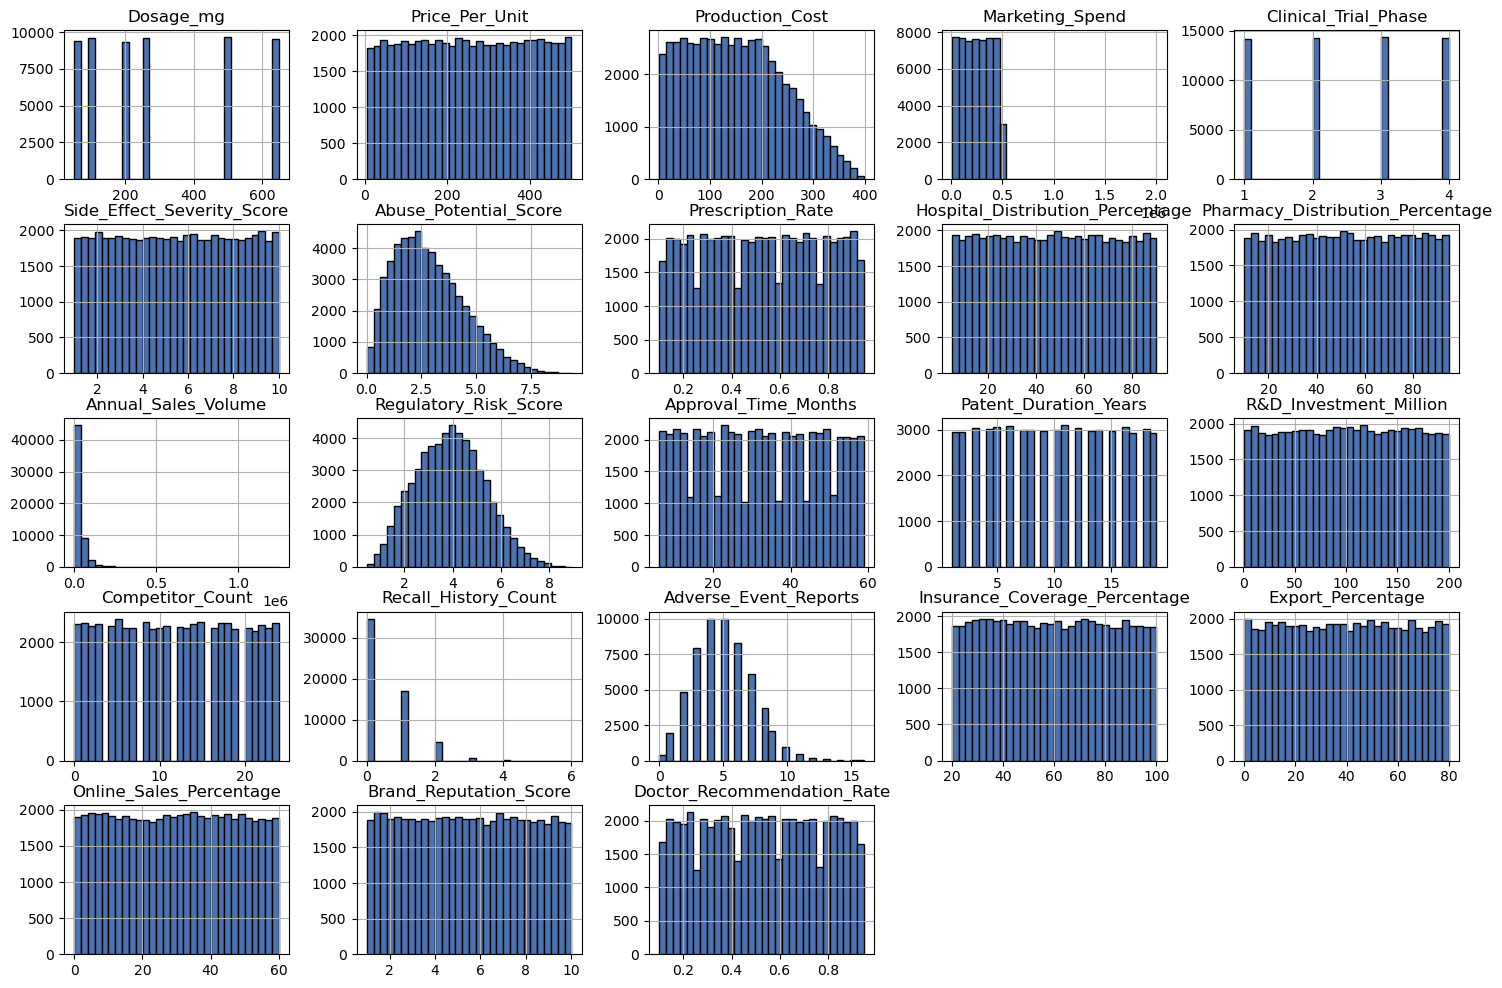

In [14]:
df.hist(figsize=(18,12),  bins=30, color='#4C72B0', edgecolor='black')

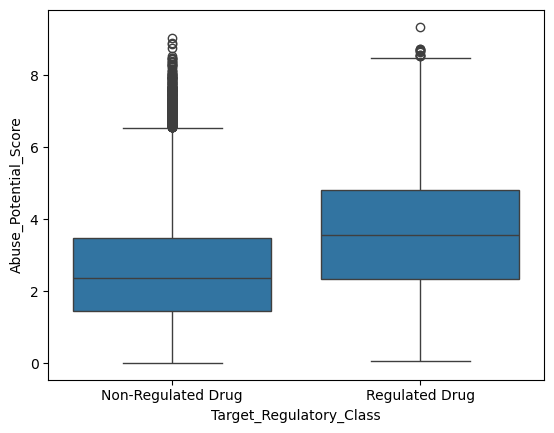

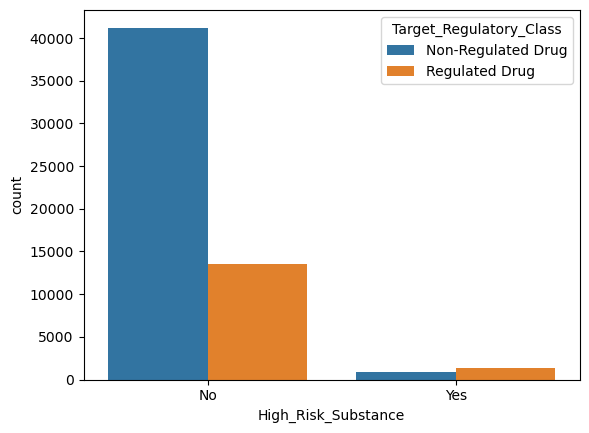

In [15]:

import seaborn as sns

# Numerical vs Target → Boxplot
sns.boxplot(data=df, x='Target_Regulatory_Class', y='Abuse_Potential_Score')
plt.show()

# Categorical vs Target → Countplot
sns.countplot(data=df, x='High_Risk_Substance', hue='Target_Regulatory_Class')
plt.show()

In [16]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
numeric_df.corr()


,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Patent_Duration_Years,R&D_Investment_Million,Competitor_Count,Recall_History_Count,Adverse_Event_Reports,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate
Dosage_mg,1.000000,-0.006688,-0.006488,0.008674,-0.002648,-0.003281,0.005486,0.003557,0.005345,-0.005345,...,0.002161,0.005496,0.001607,-0.009126,-0.007243,0.003696,0.002818,0.001090,0.003633,-0.002204
Price_Per_Unit,-0.006688,1.000000,0.931083,-0.000030,-0.004339,0.000830,-0.002302,0.001559,-0.005236,0.005236,...,-0.004994,0.001071,0.001926,0.002148,-0.003351,0.006289,-0.002614,0.006319,0.003020,0.004963
Production_Cost,-0.006488,0.931083,1.000000,-0.003675,-0.003856,-0.000102,-0.002380,-0.000520,-0.003988,0.003988,...,-0.005592,-0.000667,0.002359,0.000610,-0.002917,0.006162,-0.003131,0.005544,0.002012,0.005627
Marketing_Spend,0.008674,-0.000030,-0.003675,1.000000,0.005022,0.001359,0.005698,0.006724,0.002458,-0.002458,...,-0.005557,-0.005103,0.005613,0.002228,-0.000432,-0.002711,-0.001472,-0.001821,0.004269,-0.006215
Clinical_Trial_Phase,-0.002648,-0.004339,-0.003856,0.005022,1.000000,0.000648,-0.001540,-0.001016,-0.001975,0.001975,...,0.001182,-0.007494,-0.000175,-0.002601,-0.002590,0.001619,0.002891,0.002788,-0.004728,-0.003370
Side_Effect_Severity_Score,-0.003281,0.000830,-0.000102,0.001359,0.000648,1.000000,0.003434,0.001691,-0.005404,0.005404,...,-0.010157,0.005502,0.005636,-0.004074,-0.005131,-0.004954,0.002457,0.003400,0.003389,0.001177
Abuse_Potential_Score,0.005486,-0.002302,-0.002380,0.005698,-0.001540,0.003434,1.000000,-0.005504,-0.000193,0.000193,...,-0.004911,0.001836,0.002835,-0.002386,0.003498,-0.002110,-0.000620,-0.001961,-0.007919,0.004653
Prescription_Rate,0.003557,0.001559,-0.000520,0.006724,-0.001016,0.001691,-0.005504,1.000000,0.004345,-0.004345,...,0.002406,-0.001924,-0.005260,-0.002987,-0.001920,-0.011429,-0.004525,0.002267,0.003520,0.002627
Hospital_Distribution_Percentage,0.005345,-0.005236,-0.003988,0.002458,-0.001975,-0.005404,-0.000193,0.004345,1.000000,-1.000000,...,-0.008481,-0.007319,0.003222,0.002421,-0.001922,-0.005557,-0.002990,0.000563,-0.006271,0.006611
Pharmacy_Distribution_Percentage,-0.005345,0.005236,0.003988,-0.002458,0.001975,0.005404,0.000193,-0.004345,-1.000000,1.000000,...,0.008481,0.007319,-0.003222,-0.002421,0.001922,0.005557,0.002990,-0.000563,0.006271,-0.006611


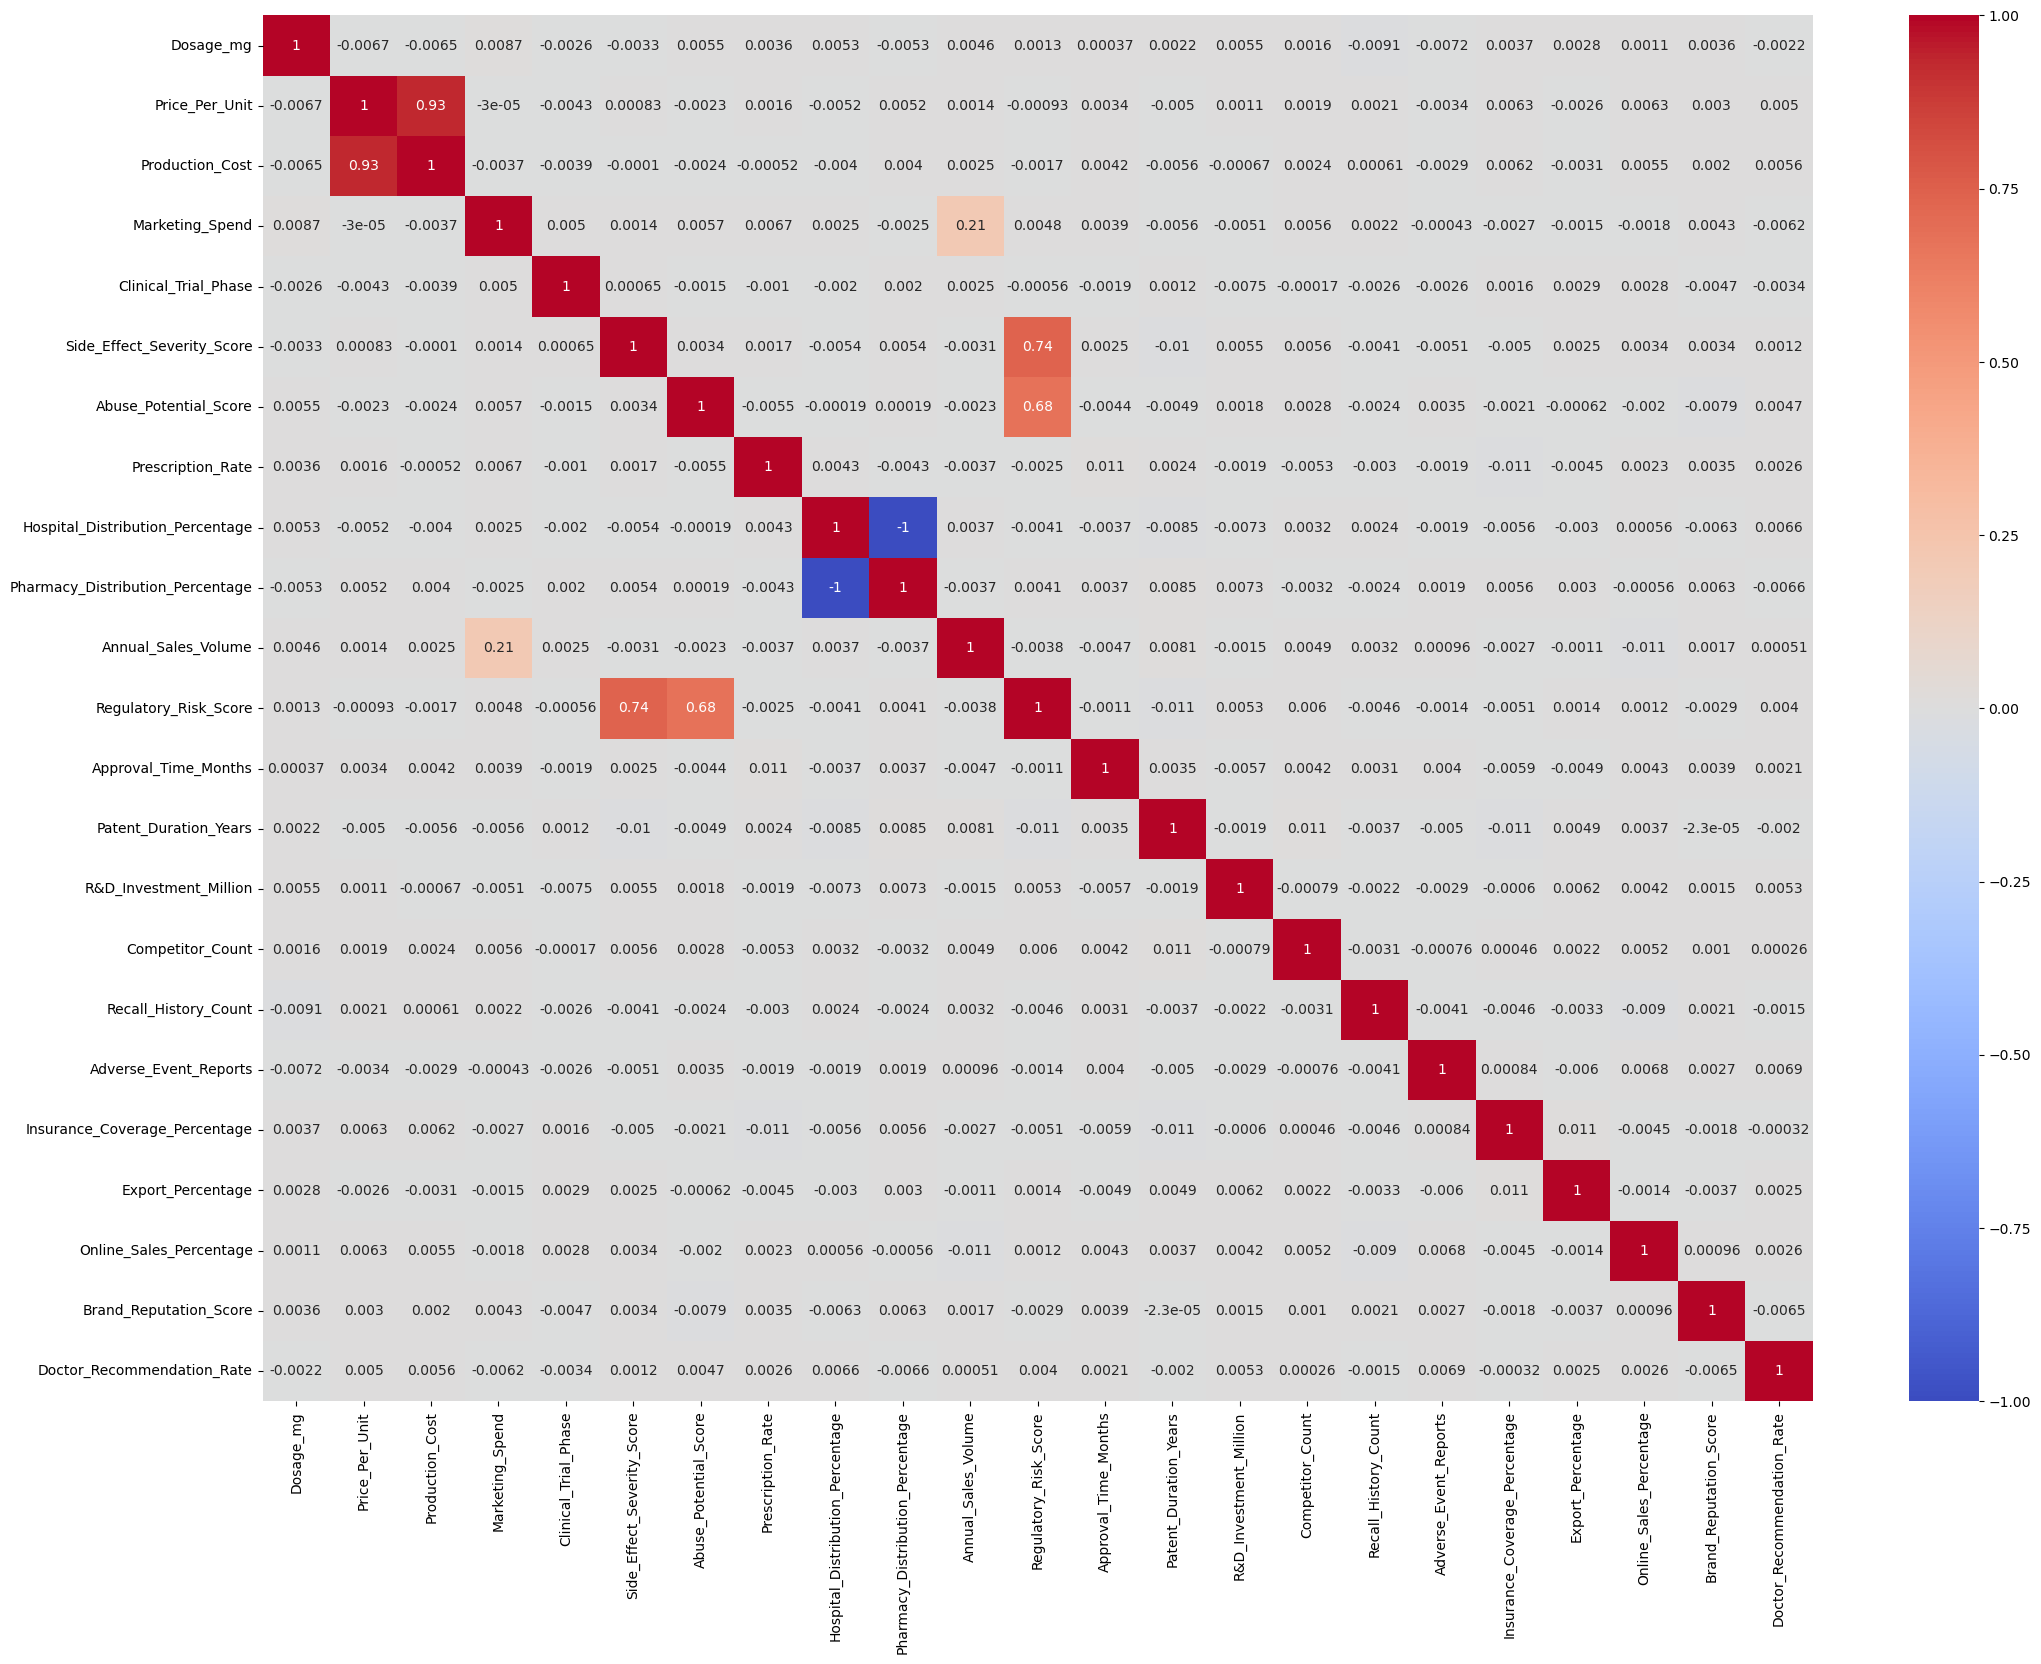

In [17]:
plt.figure(figsize=(25,18))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()


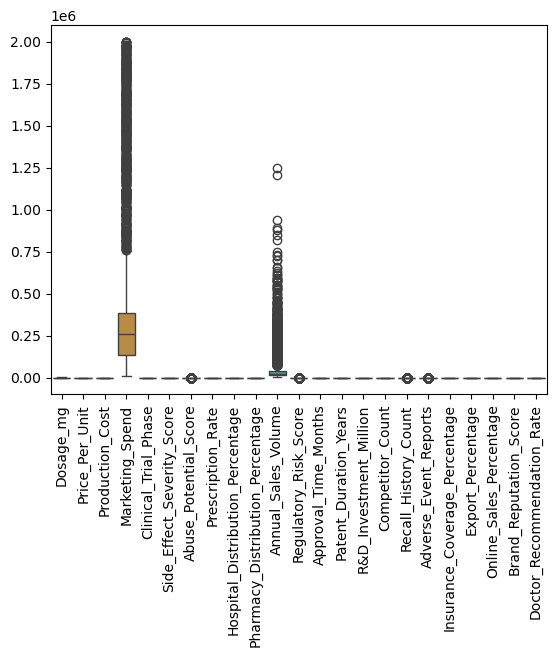

In [18]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()


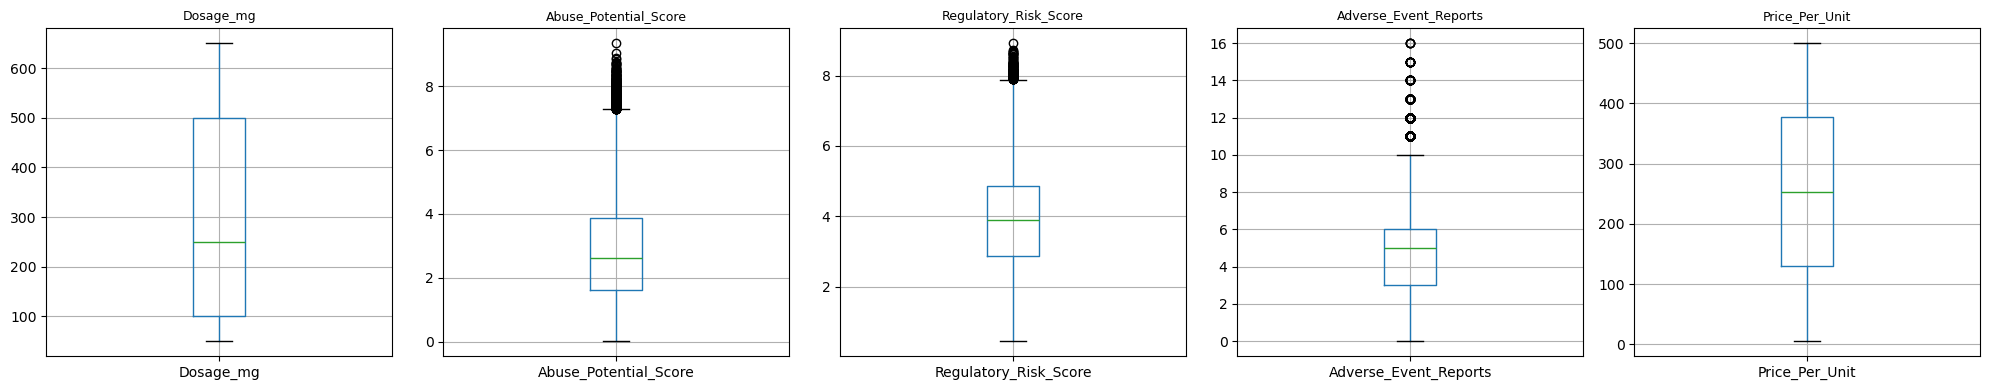

In [19]:
num_cols = ['Dosage_mg', 'Abuse_Potential_Score', 'Regulatory_Risk_Score', 
            'Adverse_Event_Reports', 'Price_Per_Unit']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

In [20]:
for col in df.select_dtypes(include='object'):
    print(df[col].value_counts())


Drug_Form
Syrup        14437
Capsule      14249
Tablet       14219
Injection    14095
Name: count, dtype: int64
Therapeutic_Class
Analgesic         11505
Antidepressant    11451
Antibiotic        11376
Antiviral         11343
Cardiovascular    11325
Name: count, dtype: int64
Manufacturing_Region
South    14401
East     14328
North    14141
West     14130
Name: count, dtype: int64
Requires_Cold_Storage
Yes    28507
No     28493
Name: count, dtype: int64
OTC_Flag
Yes    28530
No     28470
Name: count, dtype: int64
High_Risk_Substance
No     54733
Yes     2267
Name: count, dtype: int64
Target_Regulatory_Class
Non-Regulated Drug    42130
Regulated Drug        14870
Name: count, dtype: int64


In [21]:
df.select_dtypes(include=['int64','float64']).skew()




#| Value       | Meaning             |
#| ----------- | ------------------- |
#| ≈ 0         | Normal distribution |
#| > 0         | Right skewed        |
#| < 0         | Left skewed         |
#| > 1 or < -1 | Highly skewed       |



Dosage_mg                           0.543745
Price_Per_Unit                     -0.002410
Production_Cost                     0.310281
Marketing_Spend                     2.787883
Clinical_Trial_Phase               -0.004838
Side_Effect_Severity_Score         -0.000020
Abuse_Potential_Score               0.606548
Prescription_Rate                  -0.005357
Hospital_Distribution_Percentage    0.004598
Pharmacy_Distribution_Percentage   -0.004598
Annual_Sales_Volume                 7.061155
Regulatory_Risk_Score               0.176031
Approval_Time_Months                0.011580
Patent_Duration_Years               0.004688
R&D_Investment_Million             -0.006605
Competitor_Count                    0.007559
Recall_History_Count                1.406366
Adverse_Event_Reports               0.444288
Insurance_Coverage_Percentage       0.013151
Export_Percentage                   0.000896
Online_Sales_Percentage             0.000421
Brand_Reputation_Score              0.007553
Doctor_Rec

In [22]:
df.select_dtypes(include=['float64','int64']).kurtosis()

Dosage_mg                            -1.200414
Price_Per_Unit                       -1.201047
Production_Cost                      -0.776713
Marketing_Spend                      19.657858
Clinical_Trial_Phase                 -1.358686
Side_Effect_Severity_Score           -1.204066
Abuse_Potential_Score                -0.100495
Prescription_Rate                    -1.200431
Hospital_Distribution_Percentage     -1.197426
Pharmacy_Distribution_Percentage     -1.197426
Annual_Sales_Volume                 110.447992
Regulatory_Risk_Score                -0.382107
Approval_Time_Months                 -1.200906
Patent_Duration_Years                -1.203282
R&D_Investment_Million               -1.192124
Competitor_Count                     -1.204943
Recall_History_Count                  1.900374
Adverse_Event_Reports                 0.226816
Insurance_Coverage_Percentage        -1.201995
Export_Percentage                    -1.198403
Online_Sales_Percentage              -1.199416
Brand_Reputat

In [23]:
df.columns


Index(['Dosage_mg', 'Price_Per_Unit', 'Production_Cost', 'Marketing_Spend',
       'Clinical_Trial_Phase', 'Side_Effect_Severity_Score',
       'Abuse_Potential_Score', 'Prescription_Rate',
       'Hospital_Distribution_Percentage', 'Pharmacy_Distribution_Percentage',
       'Annual_Sales_Volume', 'Regulatory_Risk_Score', 'Approval_Time_Months',
       'Patent_Duration_Years', 'R&D_Investment_Million', 'Competitor_Count',
       'Recall_History_Count', 'Adverse_Event_Reports', 'Drug_Form',
       'Therapeutic_Class', 'Manufacturing_Region', 'Requires_Cold_Storage',
       'OTC_Flag', 'High_Risk_Substance', 'Insurance_Coverage_Percentage',
       'Export_Percentage', 'Online_Sales_Percentage',
       'Brand_Reputation_Score', 'Doctor_Recommendation_Rate',
       'Target_Regulatory_Class'],
      dtype='object')

In [24]:
df.dtypes


Dosage_mg                             int64
Price_Per_Unit                      float64
Production_Cost                     float64
Marketing_Spend                     float64
Clinical_Trial_Phase                  int64
Side_Effect_Severity_Score          float64
Abuse_Potential_Score               float64
Prescription_Rate                   float64
Hospital_Distribution_Percentage    float64
Pharmacy_Distribution_Percentage    float64
Annual_Sales_Volume                 float64
Regulatory_Risk_Score               float64
Approval_Time_Months                  int64
Patent_Duration_Years                 int64
R&D_Investment_Million              float64
Competitor_Count                      int64
Recall_History_Count                  int64
Adverse_Event_Reports                 int64
Drug_Form                            object
Therapeutic_Class                    object
Manufacturing_Region                 object
Requires_Cold_Storage                object
OTC_Flag                        

In [25]:
# Reload raw data before preprocessing
df = pd.read_csv(r"C:\Users\Prakash\Downloads\drug_regulatory_classification_dataset.csv")
df.dropna(subset=['Target_Regulatory_Class'], inplace=True)
print("Raw df loaded! Shape:", df.shape)  # (57000, 30)
print(df.columns.tolist())  # should show Drug_Form, Therapeutic_Class etc

Raw df loaded! Shape: (57000, 30)
['Dosage_mg', 'Price_Per_Unit', 'Production_Cost', 'Marketing_Spend', 'Clinical_Trial_Phase', 'Side_Effect_Severity_Score', 'Abuse_Potential_Score', 'Prescription_Rate', 'Hospital_Distribution_Percentage', 'Pharmacy_Distribution_Percentage', 'Annual_Sales_Volume', 'Regulatory_Risk_Score', 'Approval_Time_Months', 'Patent_Duration_Years', 'R&D_Investment_Million', 'Competitor_Count', 'Recall_History_Count', 'Adverse_Event_Reports', 'Drug_Form', 'Therapeutic_Class', 'Manufacturing_Region', 'Requires_Cold_Storage', 'OTC_Flag', 'High_Risk_Substance', 'Insurance_Coverage_Percentage', 'Export_Percentage', 'Online_Sales_Percentage', 'Brand_Reputation_Score', 'Doctor_Recommendation_Rate', 'Target_Regulatory_Class']


In [26]:


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from feature_engine.outliers import Winsorizer

# ✅ Define all columns HERE inside this cell
outlier_cols = ['Annual_Sales_Volume', 'Recall_History_Count', 'Adverse_Event_Reports']

cat_cols = ['Drug_Form', 'Therapeutic_Class', 'Manufacturing_Region',
            'Requires_Cold_Storage', 'OTC_Flag', 'High_Risk_Substance']

normal_num_cols = [col for col in df.select_dtypes(include=['int64','float64']).columns
                   if col not in outlier_cols]

print("outlier_cols  :", len(outlier_cols))
print("normal_num_cols:", len(normal_num_cols))
print("cat_cols      :", len(cat_cols))
print("df columns    :", df.columns.tolist())  # verify raw columns exist

# Pipelines
outlier_pipeline = Pipeline([
    ('imputer',    SimpleImputer(strategy='median')),
    ('winsorizer', Winsorizer(capping_method='iqr', tail='both', fold=1.5)),
    ('scaler',     StandardScaler())
])

normal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # ✅ key fix
])

preprocessor = ColumnTransformer([
    ('outlier_num', outlier_pipeline,     outlier_cols),
    ('normal_num',  normal_pipeline,      normal_num_cols),
    ('cat',         categorical_pipeline, cat_cols)
])

print("✅ Preprocessor ready!")

outlier_cols  : 3
normal_num_cols: 20
cat_cols      : 6
df columns    : ['Dosage_mg', 'Price_Per_Unit', 'Production_Cost', 'Marketing_Spend', 'Clinical_Trial_Phase', 'Side_Effect_Severity_Score', 'Abuse_Potential_Score', 'Prescription_Rate', 'Hospital_Distribution_Percentage', 'Pharmacy_Distribution_Percentage', 'Annual_Sales_Volume', 'Regulatory_Risk_Score', 'Approval_Time_Months', 'Patent_Duration_Years', 'R&D_Investment_Million', 'Competitor_Count', 'Recall_History_Count', 'Adverse_Event_Reports', 'Drug_Form', 'Therapeutic_Class', 'Manufacturing_Region', 'Requires_Cold_Storage', 'OTC_Flag', 'High_Risk_Substance', 'Insurance_Coverage_Percentage', 'Export_Percentage', 'Online_Sales_Percentage', 'Brand_Reputation_Score', 'Doctor_Recommendation_Rate', 'Target_Regulatory_Class']
✅ Preprocessor ready!


In [27]:
# X from RAW df — categorical columns still exist here
X = df[outlier_cols + normal_num_cols + cat_cols]
y = df['Target_Regulatory_Class']

print("X shape:", X.shape)   # (57000, 29)
print("y shape:", y.shape)   # (57000,)

X shape: (57000, 29)
y shape: (57000,)


In [28]:
transformed_array = preprocessor.fit_transform(X)

In [29]:
ohe_feature_names = preprocessor.named_transformers_['cat']\
                    .named_steps['encoder']\
                    .get_feature_names_out(cat_cols).tolist()


all_feature_names = outlier_cols + normal_num_cols + ohe_feature_names

In [30]:
clean_data = pd.DataFrame(transformed_array, columns=all_feature_names)

In [31]:
clean_data['Target_Regulatory_Class'] = y.values



In [32]:
clean_data.to_csv("Clean_Drug.csv", index=False)

In [33]:
clean_data.shape


(57000, 43)

In [34]:
clean_data.to_csv("Clean_Drug.csv", index=False)
print("✅ Clean_Drug.csv saved!")

✅ Clean_Drug.csv saved!


In [35]:
# Load clean data into clean_df
clean_df = pd.read_csv('Clean_Drug.csv')

X = clean_df.drop('Target_Regulatory_Class', axis=1)
y = clean_df['Target_Regulatory_Class']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (57000, 42)
y shape: (57000,)


In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)
print("Before:", y[:3].values)
print("After :", y_encoded[:3])

Classes: ['Non-Regulated Drug' 'Regulated Drug']
Before: ['Non-Regulated Drug' 'Non-Regulated Drug' 'Non-Regulated Drug']
After : [0 0 0]


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (45600, 42)
X_test : (11400, 42)


In [38]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    
    max_iter=1000,
    random_state=42
)
print("Training... ⏳")
model_lr.fit(X_train, y_train)
print("✅ Training Done!")



Training... ⏳
✅ Training Done!


In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model_lr.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 78.48 %

Classification Report:
                    precision    recall  f1-score   support

Non-Regulated Drug       0.81      0.92      0.86      8426
    Regulated Drug       0.64      0.39      0.49      2974

          accuracy                           0.78     11400
         macro avg       0.73      0.66      0.68     11400
      weighted avg       0.77      0.78      0.77     11400


Confusion Matrix:
[[7779  647]
 [1806 1168]]


In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Build KNN model
model_knn = KNeighborsClassifier(
    n_neighbors=5,      # look at 5 nearest neighbors
    metric='euclidean', # distance measurement
    n_jobs=-1           # use all CPU cores for speed
)

print("Training... ⏳")
model_knn.fit(X_train, y_train)
print("✅ Training Done!")

Training... ⏳
✅ Training Done!


In [39]:
y_pred_knn = model_knn.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_knn)*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

Accuracy: 74.48 %

Classification Report:
                    precision    recall  f1-score   support

Non-Regulated Drug       0.79      0.89      0.84      8426
    Regulated Drug       0.52      0.33      0.40      2974

          accuracy                           0.74     11400
         macro avg       0.65      0.61      0.62     11400
      weighted avg       0.72      0.74      0.72     11400


Confusion Matrix:
[[7524  902]
 [2007  967]]


In [40]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Sample 15k rows — enough for rbf to show real patterns
X_svm, _, y_svm, _ = train_test_split(
    X_train, y_train,
    train_size=15000,        # fixed 15k rows
    random_state=42,
    stratify=y_train
)

model_svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',           # auto-scales based on features
    class_weight='balanced',
    probability=True,        # keep this for Flask later
    random_state=42
)

print("Training SVM on 15k rows with rbf... ⏳")
model_svm.fit(X_svm, y_svm)
print("✅ Done!")

y_pred_svm = model_svm.predict(X_test)  # still test on full test set

Training SVM on 15k rows with rbf... ⏳
✅ Done!


In [41]:
y_pred_svm = model_svm.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_svm)*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 71.64 %

Classification Report:
                    precision    recall  f1-score   support

Non-Regulated Drug       0.88      0.72      0.79      8426
    Regulated Drug       0.47      0.71      0.57      2974

          accuracy                           0.72     11400
         macro avg       0.67      0.72      0.68     11400
      weighted avg       0.77      0.72      0.73     11400


Confusion Matrix:
[[6048 2378]
 [ 855 2119]]


In [42]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_ann = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    batch_size=512,
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=42,
    verbose=True            # shows progress
)

print("Training ANN... ⏳")
model_ann.fit(X_train, y_train)
print("✅ Done!")

y_pred_ann = model_ann.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_ann)*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann, target_names=le.classes_))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ann))

Training ANN... ⏳
Iteration 1, loss = 0.50562620
Validation score: 0.777851
Iteration 2, loss = 0.46200535
Validation score: 0.784868
Iteration 3, loss = 0.45833797
Validation score: 0.786623
Iteration 4, loss = 0.45630385
Validation score: 0.787500
Iteration 5, loss = 0.45475944
Validation score: 0.787061
Iteration 6, loss = 0.45346612
Validation score: 0.783991
Iteration 7, loss = 0.45199594
Validation score: 0.785526
Iteration 8, loss = 0.45064024
Validation score: 0.787500
Iteration 9, loss = 0.44953467
Validation score: 0.787281
Iteration 10, loss = 0.44865356
Validation score: 0.785746
Validation score did not improve more than tol=0.000100 for 5 consecutive epochs. Stopping.
✅ Done!
Accuracy: 78.31 %

Classification Report:
                    precision    recall  f1-score   support

Non-Regulated Drug       0.81      0.93      0.86      8426
    Regulated Drug       0.65      0.37      0.47      2974

          accuracy                           0.78     11400
         macro av

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_dt = DecisionTreeClassifier(
    criterion='gini',          # split quality: 'gini' or 'entropy'
    max_depth=10,              # max depth of the tree
    min_samples_split=5,       # min samples to split a node
    min_samples_leaf=2,        # min samples at a leaf
    max_features=None,         # features to consider per split
    class_weight='balanced',   # handles class imbalance
    random_state=42
)

print("Training Decision Tree... ⏳")
model_dt.fit(X_train, y_train)
print("✅ Done!")

y_pred_dt = model_dt.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_dt) * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Training Decision Tree... ⏳
✅ Done!
Accuracy: 68.84 %

Classification Report:
                    precision    recall  f1-score   support

Non-Regulated Drug       0.87      0.68      0.76      8426
    Regulated Drug       0.44      0.72      0.55      2974

          accuracy                           0.69     11400
         macro avg       0.66      0.70      0.65     11400
      weighted avg       0.76      0.69      0.71     11400


Confusion Matrix:
[[5704 2722]
 [ 830 2144]]


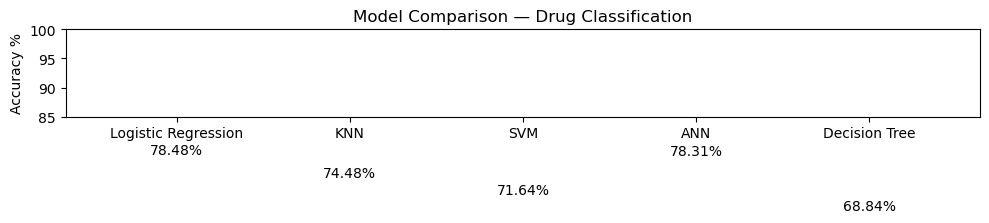

In [47]:
results = {
    'Logistic Regression': accuracy_score(y_test, y_pred),
    'KNN':                 accuracy_score(y_test, y_pred_knn),
    'SVM':                 accuracy_score(y_test, y_pred_svm),
    'ANN':                 accuracy_score(y_test, y_pred_ann),
    'Decision Tree':       accuracy_score(y_test, y_pred_dt),
}

plt.figure(figsize=(10, 8))
bars = plt.bar(results.keys(), [v*100 for v in results.values()], 
               color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'])
plt.ylim(85, 100)   # zoom in to show differences clearly
plt.ylabel('Accuracy %')
plt.title('Model Comparison — Drug Classification')
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.1, 
             f'{val*100:.2f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [41]:
import os
os.makedirs('models', exist_ok=True)
print("Folder created:", os.getcwd())  # shows you WHERE the folder was created

Folder created: C:\Users\Prakash\Desktop\Project_DATAMITES


In [42]:
import pickle
 
# ✅ STEP 1 — Save the trained Logistic Regression model
pickle.dump(model_lr, open('models/model.pkl', 'wb'))
print("✅ model.pkl saved!")
 
# ✅ STEP 2 — Save the preprocessor (ColumnTransformer pipeline)
pickle.dump(preprocessor, open('models/preprocessor.pkl', 'wb'))
print("✅ preprocessor.pkl saved!")
 
# ✅ STEP 3 — Save the LabelEncoder (converts 0,1,2 back to drug names)
pickle.dump(le, open('models/label_encoder.pkl', 'wb'))
print("✅ label_encoder.pkl saved!")
 
print("\n🎉 All 3 files saved inside models/ folder!")
print("Files saved:")
print("  - models/model.pkl")
print("  - models/preprocessor.pkl")
print("  - models/label_encoder.pkl")
 

✅ model.pkl saved!
✅ preprocessor.pkl saved!
✅ label_encoder.pkl saved!

🎉 All 3 files saved inside models/ folder!
Files saved:
  - models/model.pkl
  - models/preprocessor.pkl
  - models/label_encoder.pkl


In [43]:
import os
print(os.getcwd())


C:\Users\Prakash\Desktop\Project_DATAMITES


In [44]:
print(df.iloc[0])


Dosage_mg                                          250
Price_Per_Unit                                  364.22
Production_Cost                                 246.49
Marketing_Spend                              159132.53
Clinical_Trial_Phase                                 3
Side_Effect_Severity_Score                        4.26
Abuse_Potential_Score                             2.52
Prescription_Rate                                 0.74
Hospital_Distribution_Percentage                 57.93
Pharmacy_Distribution_Percentage                 42.07
Annual_Sales_Volume                           32204.94
Regulatory_Risk_Score                             3.22
Approval_Time_Months                                21
Patent_Duration_Years                               19
R&D_Investment_Million                          149.98
Competitor_Count                                     3
Recall_History_Count                                 1
Adverse_Event_Reports                                6
Drug_Form 